<a href="https://colab.research.google.com/github/mixxr/gcolab-ml/blob/main/funnel/05_similarity_search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Episode 5 — Similarity Search
**Drug Discovery in Code** · [Life Sciences AI Applications]
You have one molecule you like — a known inhibitor — and a big pile of others. **Which ones look
like it?** That's *similarity search*, and it's one of the most-used moves in real discovery:
start from something that works and find its neighbours. We'll use the fingerprints and **Tanimoto**
similarity from Episode 2, applied to the drug-like EGFR set from Episode 4.
> Educational only — not medical advice.

## RDKit Setup

In [1]:
! wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
! bash Miniconda3-latest-Linux-x86_64.sh -b -f -p /usr/local

--2026-10-09 13:11:20--  https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.191.158, 104.16.32.241, 2606:4700::6810:20f1, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.191.158|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 197973354 (189M) [application/octet-stream]
Saving to: ‘Miniconda3-latest-Linux-x86_64.sh’

Miniconda3-latest-L 100%[===================>] 188.80M   138MB/s    in 1.4s    

2026-10-09 13:11:21 (138 MB/s) - ‘Miniconda3-latest-Linux-x86_64.sh’ saved [197973354/197973354]

PREFIX=/usr/local
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please

In [2]:
import sys
!{sys.executable} -m pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 17.2 MB/s eta 0:00:00


## Setup — the drug-like set + a query molecule
Our query is **gefitinib**, a real approved EGFR inhibitor. We want its look-alikes.

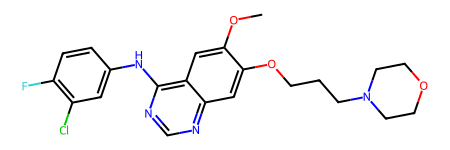

In [3]:
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, rdFingerprintGenerator

df = pd.read_csv("egfr_druglike.csv")

# gefitinib
query_smiles = "COc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCCN1CCOCC1"
query = Chem.MolFromSmiles(query_smiles)
query

## 1. Fingerprint everything
Same Morgan generator as Episode 2 — turn every molecule (and the query) into a 2048-bit barcode.

In [4]:
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

query_fp = gen.GetFingerprint(query)
# for each molecule in the df => compute the Fingerprint
fps = [gen.GetFingerprint(Chem.MolFromSmiles(s)) for s in df.smiles]
print("Computed ", len(fps), "Fingerprints")

Computed  4729 Fingerprints


## 2. Score by Tanimoto and rank
`BulkTanimotoSimilarity` compares the query against every fingerprint at once — fast, even for
thousands of molecules.

In [15]:
# compare the query mol with all molecules in the df
df["tanimoto"] = DataStructs.BulkTanimotoSimilarity(query_fp, fps)
df.to_csv("05_similarities.csv")
print("Total Fingerprints:", len(df))
print("Total Duplicates:", len(df[df.tanimoto >= 0.999]))
df.sort_values("tanimoto", ascending=False).head(6)

Total Fingerprints: 4729
Total Duplicates: 1


,molecule_chembl_id,smiles,IC50_nM,pIC50,MolWt,LogP,HBD,HBA,violations,ro5_pass,pains,tanimoto
1150,CHEMBL939,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,22.0,7.657577,446.910,4.2756,1.0,7.0,0,True,False,1.000000
814,CHEMBL14699,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCN1CCOCC1,10.0,8.000000,432.883,3.8855,1.0,7.0,0,True,False,0.919355
1733,CHEMBL299672,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCCC1,71.0,7.148742,430.911,5.0392,1.0,6.0,1,True,False,0.857143
1775,CHEMBL291514,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCCCC1,79.0,7.102373,444.938,5.4293,1.0,6.0,1,True,False,0.843750
717,CHEMBL4586581,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCNCCNCC1,8.3,8.080922,488.995,3.4382,3.0,8.0,0,True,False,0.805970
625,CHEMBL4534611,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCNCCN...,6.6,8.180456,532.064,3.0278,4.0,9.0,1,True,False,0.805970


In [14]:
# drop duplicates and use the top 6 molecules
hits = (df[df.tanimoto < 0.999]
          .sort_values("tanimoto", ascending=False)
          .head(6))
print("Total Hits:", len(hits))
hits[["molecule_chembl_id", "smiles","tanimoto", "pIC50"]].round(2)

Total Hits: 6


,molecule_chembl_id,smiles,tanimoto,pIC50
814,CHEMBL14699,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCN1CCOCC1,0.92,8.00
1733,CHEMBL299672,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCCC1,0.86,7.15
1775,CHEMBL291514,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCCCC1,0.84,7.10
625,CHEMBL4534611,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCNCCN...,0.81,8.18
717,CHEMBL4586581,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCNCCNCC1,0.81,8.08
1840,CHEMBL57758,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCN1CCCC1,0.78,7.06


## 3. Look at the neighbours
The whole point of a scaffold-based search: the top hits should *visibly* resemble the query.

<class 'PIL.PngImagePlugin.PngImageFile'>


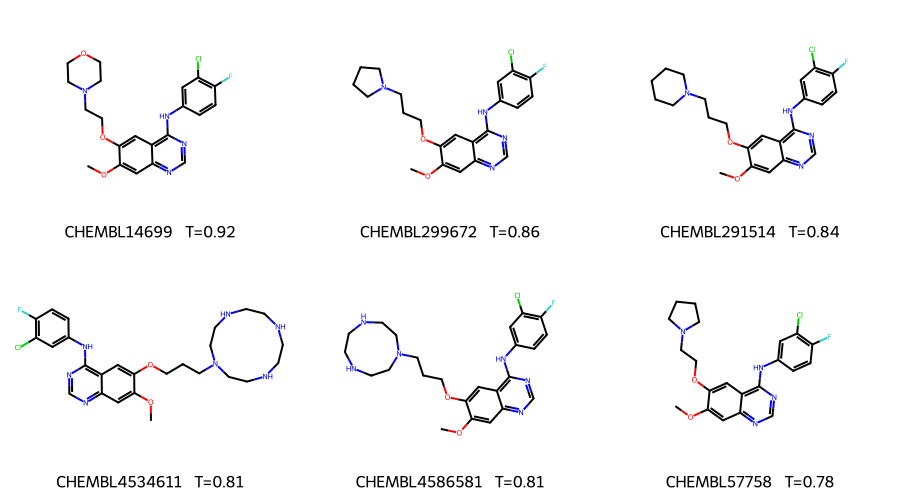

In [20]:
mols = [Chem.MolFromSmiles(s) for s in hits.smiles]
legends = [f"{cid}  T={t:.2f}"
           for cid, t in zip(hits.molecule_chembl_id, hits.tanimoto)]
img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300,250), legends=legends,
    useSVG=False,
    returnPNG=False)
img.save("05_neighbours.png")
img

Every hit shares gefitinib's **anilino-quinazoline** core — same chloro-fluoro-phenyl on one side,
same fused ring system — differing mainly in the solubilising tail. That's exactly what a good
similarity search surfaces: **the same idea, explored different ways.**

## 4. How similar is *similar*?
Plot the similarity of the whole set to the query. Most molecules are unrelated (low Tanimoto);
only a handful cluster up near the query — the true analogues.

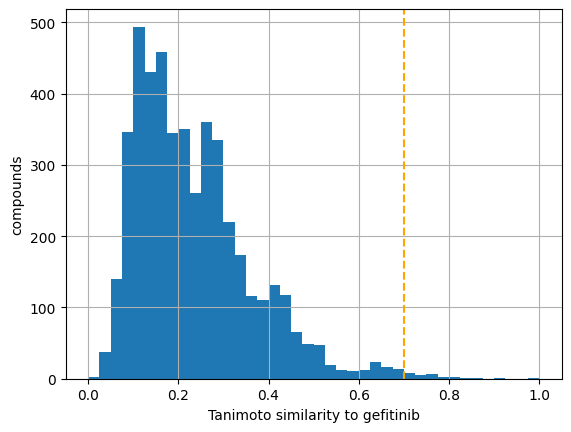

32 compounds are >= 0.70 similar


In [10]:
import matplotlib.pyplot as plt
df.tanimoto.hist(bins=40)
plt.axvline(0.7, ls="--", c="orange")   # a common "similar" threshold
plt.xlabel("Tanimoto similarity to gefitinib"); plt.ylabel("compounds"); plt.show()

print((df.tanimoto >= 0.7).sum(), "compounds are >= 0.70 similar")

Similarity search is the workhorse of **lead hopping** and **analogue finding** — and the same
machinery powers searching millions of purchasable molecules for look-alikes of a hit.

## Recap
- **Similarity search** = fingerprint the query, fingerprint the library, rank by Tanimoto.
- `BulkTanimotoSimilarity` scores thousands of molecules in one call.
- Top hits share the query's scaffold — visibly the same chemical series.
- Most of a set is dissimilar; the analogues are a small, high-Tanimoto tail.

**Next — Episode 6:** stop eyeballing and **train a model** — a QSAR regressor that predicts pIC50
from fingerprints, on this very dataset.